# 🩸 Diabetes Risk Prediction: ML for Chronic Disease Screening & Hospital Readmission

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting diabetes risk from clinical measurements to support preventive health screening and hospital readmission reduction  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting diabetes risk using clinical indicators (glucose, blood pressure, BMI, insulin, age, pregnancies). The model supports **population-level chronic disease screening**, **GP decision support**, and **hospital readmission prevention**.

### Government Policy Context
- **Department of Health & Aged Care** — National Diabetes Strategy 2021-2030, Medicare Chronic Disease Management
- **AIHW** — National Diabetes Register, burden of disease surveillance, hospitalisations data
- **NDSS (National Diabetes Services Scheme)** — Diabetes management support, subsidised products
- **Medicare** — GP Management Plans (item 721), Team Care Arrangements (item 723), HbA1c monitoring
- **PBS** — Metformin/insulin utilisation, GLP-1 receptor agonist access, cost-effectiveness

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High diabetes risk | Oral glucose tolerance test, HbA1c, urgent GP review | GP + endocrinologist |
| Moderate risk | Lifestyle intervention, 3-month fasting glucose retest | GP + practice nurse |
| Low risk (confident) | Annual screening with routine bloods | Automated recall |
| Low risk (BMI/family history) | Targeted prevention program, dietitian referral | Allied health |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/nancyalaswad90/review/diabetes.csv

Using: /kaggle/input/datasets/nancyalaswad90/review/diabetes.csv
Loaded: 768 rows x 9 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    zeros = (df[col] == 0).sum() if df[col].dtype in ['int64', 'float64'] else 0
    print(f"  {i:2d}. {col:30s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | zeros={zeros:3d}")
df.head()


COLUMN SUMMARY
   0. Pregnancies                    | int64      | unique=   17 | nulls=  0 | zeros=111
   1. Glucose                        | int64      | unique=  136 | nulls=  0 | zeros=  5
   2. BloodPressure                  | int64      | unique=   47 | nulls=  0 | zeros= 35
   3. SkinThickness                  | int64      | unique=   51 | nulls=  0 | zeros=227
   4. Insulin                        | int64      | unique=  186 | nulls=  0 | zeros=374
   5. BMI                            | float64    | unique=  248 | nulls=  0 | zeros= 11
   6. DiabetesPedigreeFunction       | float64    | unique=  517 | nulls=  0 | zeros=  0
   7. Age                            | int64      | unique=   52 | nulls=  0 | zeros=  0
   8. Outcome                        | int64      | unique=    2 | nulls=  0 | zeros=500


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Target Variable Analysis

In [4]:
# Known targets for diabetes datasets
target_candidates = ['Outcome', 'outcome', 'diabetes', 'Diabetes', 'Diabetes_binary',
                     'target', 'Target', 'class', 'Class', 'label']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

if df[target_col].dtype == 'object':
    yes_kw = ['Yes', 'yes', '1', 'Positive', 'diabetic']
    mapping = {v: (1 if v in yes_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'Outcome'

Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Imbalance ratio: 0.536


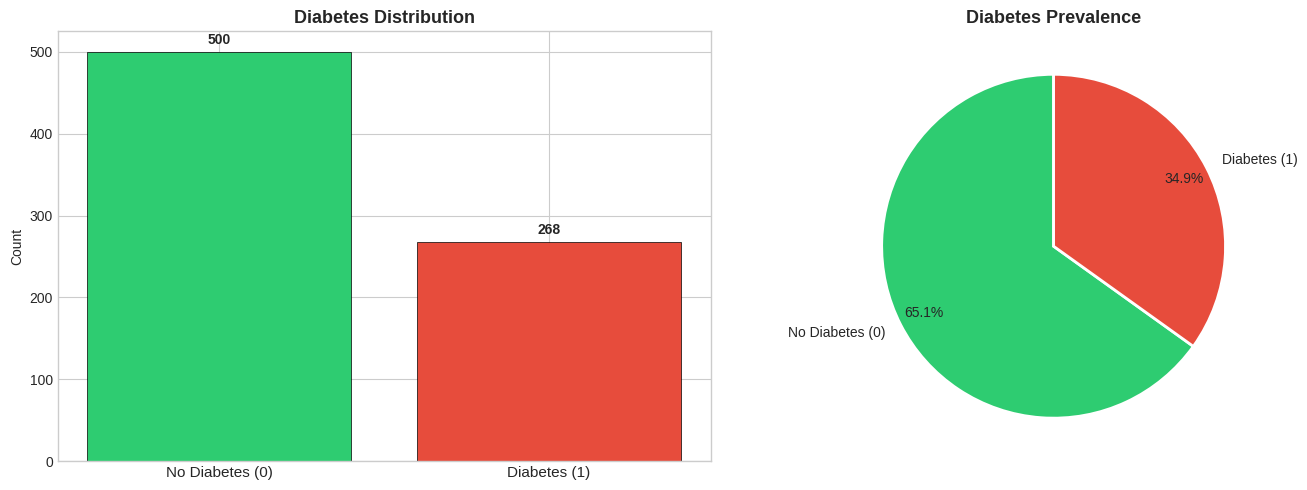

AU context: ~1.3M Australians have diagnosed diabetes (AIHW).
Type 2 diabetes accounts for ~85% of cases. Hospitalisations cost ~$1.7B p.a.
NDSS supports 1.5M+ registered Australians with diabetes management.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Diabetes Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: ~1.3M Australians have diagnosed diabetes (AIHW).")
print("Type 2 diabetes accounts for ~85% of cases. Hospitalisations cost ~$1.7B p.a.")
print("NDSS supports 1.5M+ registered Australians with diabetes management.")


## 3. Exploratory Data Analysis

Key clinical questions:
- Which clinical measurements best predict diabetes (glucose, BMI, insulin)?
- Are there threshold values that indicate high risk (e.g., fasting glucose > 7.0)?
- How does age interact with other risk factors?
- Are zero values in features (e.g., insulin=0) actually missing data?


Numeric features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Zero-value analysis (potential missing data):
  Glucose                       :    5 zeros (0.7%)
  BloodPressure                 :   35 zeros (4.6%)
  SkinThickness                 :  227 zeros (29.6%)
  Insulin                       :  374 zeros (48.7%)
  BMI                           :   11 zeros (1.4%)


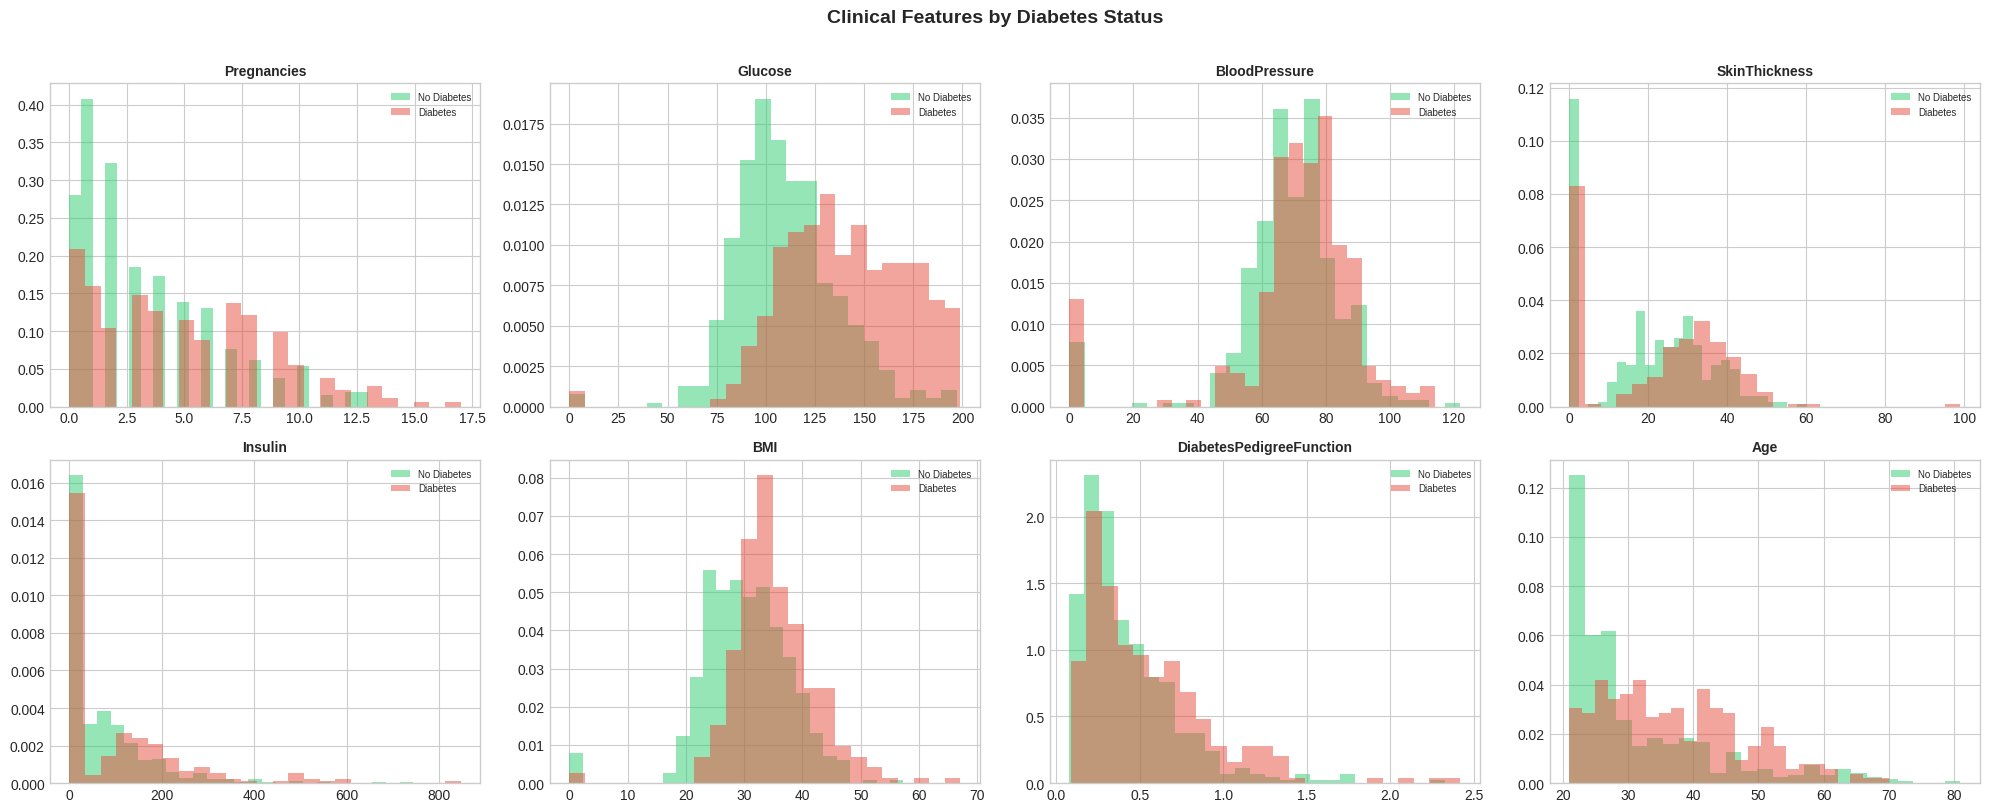

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

# Check for zero values that are likely missing
print("\nZero-value analysis (potential missing data):")
for col in numeric_cols:
    n_zeros = (df[col] == 0).sum()
    if n_zeros > 0 and col.lower() not in ['pregnancies']:
        print(f"  {col:30s}: {n_zeros:4d} zeros ({n_zeros/len(df)*100:.1f}%)")

plot_cols = numeric_cols[:8]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 3) // 4
    fig, axes = plt.subplots(n_rows_p, 4, figsize=(20, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No Diabetes', 'Diabetes']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Clinical Features by Diabetes Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


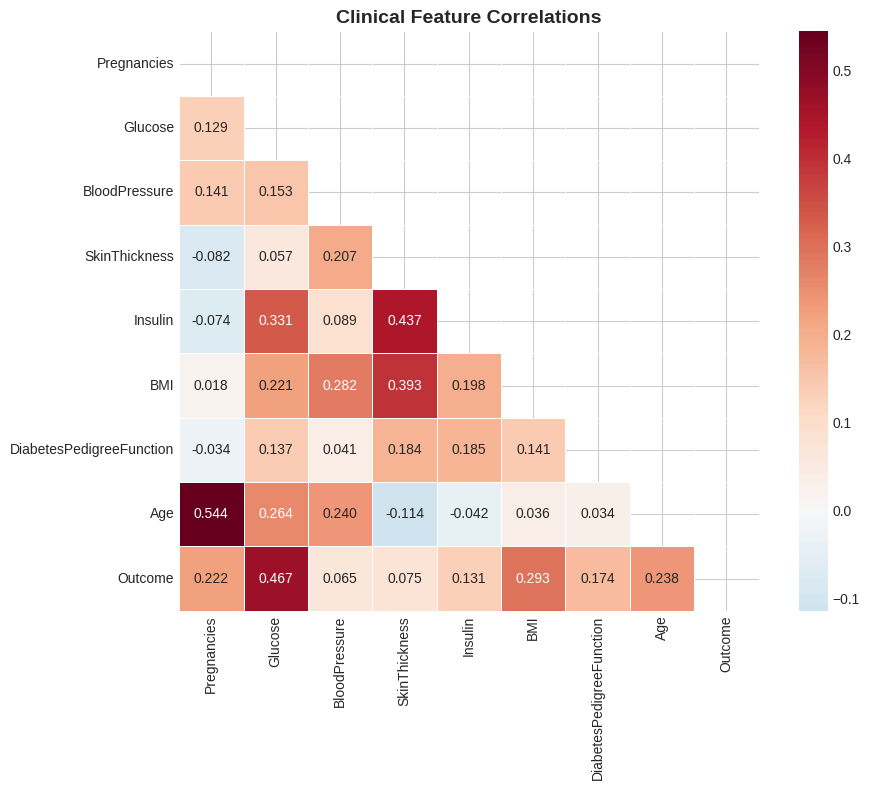

Correlations with diabetes:
  Glucose                        +0.4666
  BMI                            +0.2927
  Age                            +0.2384
  Pregnancies                    +0.2219
  DiabetesPedigreeFunction       +0.1738
  Insulin                        +0.1305
  SkinThickness                  +0.0748
  BloodPressure                  +0.0651


In [7]:
corr = df[numeric_cols + [target_col]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Clinical Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
print("Correlations with diabetes:")
for feat, val in target_corr.items():
    direction = "+" if corr.loc[feat, target_col] > 0 else "-"
    print(f"  {feat:30s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

In [8]:
df_model = df.copy()

# Replace biologically impossible zeros with NaN then impute
zero_impute_cols = [c for c in numeric_cols if c.lower() in
    ['glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi',
     'blood pressure', 'skin thickness', 'plasma glucose']]
for col in zero_impute_cols:
    if col in df_model.columns:
        n_zeros = (df_model[col] == 0).sum()
        if n_zeros > 0:
            df_model[col] = df_model[col].replace(0, np.nan)
            median_val = df_model[col].median()
            df_model[col] = df_model[col].fillna(median_val)
            print(f"  Replaced {n_zeros} zeros in '{col}' with median ({median_val:.1f})")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Drop any remaining non-numeric
X = X.select_dtypes(include=[np.number])

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


  Replaced 5 zeros in 'Glucose' with median (117.0)
  Replaced 35 zeros in 'BloodPressure' with median (72.0)
  Replaced 227 zeros in 'SkinThickness' with median (29.0)
  Replaced 374 zeros in 'Insulin' with median (125.0)
  Replaced 11 zeros in 'BMI' with median (32.3)

Feature matrix: (768, 8)
Target: {np.int64(0): np.int64(500), np.int64(1): np.int64(268)}


In [9]:
feature_names = X.columns.tolist()
composites_added = []

# BMI risk categories
bmi_cols = [c for c in feature_names if 'bmi' in c.lower()]
if bmi_cols:
    X['bmi_obese'] = (X[bmi_cols[0]] >= 30).astype(int)
    X['bmi_overweight'] = ((X[bmi_cols[0]] >= 25) & (X[bmi_cols[0]] < 30)).astype(int)
    composites_added.extend(['bmi_obese', 'bmi_overweight'])
    print("Created 'bmi_obese' (>=30) and 'bmi_overweight' (25-30)")

# Glucose risk
glucose_cols = [c for c in feature_names if 'glucose' in c.lower()]
if glucose_cols:
    X['glucose_high'] = (X[glucose_cols[0]] >= 140).astype(int)
    X['glucose_prediabetic'] = ((X[glucose_cols[0]] >= 100) & (X[glucose_cols[0]] < 140)).astype(int)
    composites_added.extend(['glucose_high', 'glucose_prediabetic'])
    print("Created 'glucose_high' (>=140) and 'glucose_prediabetic' (100-140)")

# Age risk
age_cols = [c for c in feature_names if 'age' in c.lower()]
if age_cols:
    X['age_over_45'] = (X[age_cols[0]] >= 45).astype(int)
    composites_added.append('age_over_45')
    print("Created 'age_over_45'")

# Multi-risk factor count
risk_flags = [c for c in X.columns if c in ['bmi_obese', 'glucose_high', 'age_over_45']]
if len(risk_flags) >= 2:
    X['diabetes_risk_count'] = X[risk_flags].sum(axis=1)
    composites_added.append('diabetes_risk_count')
    print(f"Created 'diabetes_risk_count' from {risk_flags}")

# BMI-glucose interaction
if bmi_cols and glucose_cols:
    X['bmi_glucose'] = X[bmi_cols[0]] * X[glucose_cols[0]] / 100
    composites_added.append('bmi_glucose')
    print("Created 'bmi_glucose' interaction")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'bmi_obese' (>=30) and 'bmi_overweight' (25-30)
Created 'glucose_high' (>=140) and 'glucose_prediabetic' (100-140)
Created 'age_over_45'
Created 'diabetes_risk_count' from ['bmi_obese', 'glucose_high', 'age_over_45']
Created 'bmi_glucose' interaction

Engineered: 7
Final feature count: 15


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.7617  F1=0.6211  AUC=0.8369
  Fold 2: Acc=0.7773  F1=0.6174  AUC=0.8522
  Fold 3: Acc=0.7344  F1=0.6304  AUC=0.8213
  -- Acc: 0.7578  F1: 0.6230  AUC: 0.8368  Time: 1.23s

Training: Random Forest
  Fold 1: Acc=0.7695  F1=0.6380  AUC=0.8375
  Fold 2: Acc=0.7773  F1=0.6415  AUC=0.8358
  Fold 3: Acc=0.7422  F1=0.6489  AUC=0.8100
  -- Acc: 0.7630  F1: 0.6428  AUC: 0.8278  Time: 1.62s

Training: XGBoost
  Fold 1: Acc=0.7578  F1=0.6173  AUC=0.8196
  Fold 2: Acc=0.7266  F1=0.5930  AUC=0.8019
  Fold 3: Acc=0.7539  F1=0.6519  AUC=0.7840
  -- Acc: 0.7461  F1: 0.6207  AUC: 0.8018  Time: 0.37s

Training: LightGBM
  Fold 1: Acc=0.7656  F1=0.6386  AUC=0.8307
  Fold 2: Acc=0.7344  F1=0.6092  AUC=0.8055
  Fold 3: Acc=0.7422  F1=0.6250  AUC=0.7953
  -- Acc: 0.7474  F1: 0.6242  AUC: 0.8105  Time: 0.28s


## 6. Model Comparison & Selection

In [12]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
Logistic Regression 0.7578 +/- 0.0178 0.6230 +/- 0.0055 0.8368 +/- 0.0126 0.1571 1.23s
      Random Forest 0.7630 +/- 0.0151 0.6428 +/- 0.0045 0.8278 +/- 0.0126 0.1613 1.62s
           LightGBM 0.7474 +/- 0.0133 0.6242 +/- 0.0120 0.8105 +/- 0.0149 0.1888 0.28s
            XGBoost 0.7461 +/- 0.0139 0.6207 +/- 0.0242 0.8018 +/- 0.0146 0.1985 0.37s

Best model: Logistic Regression


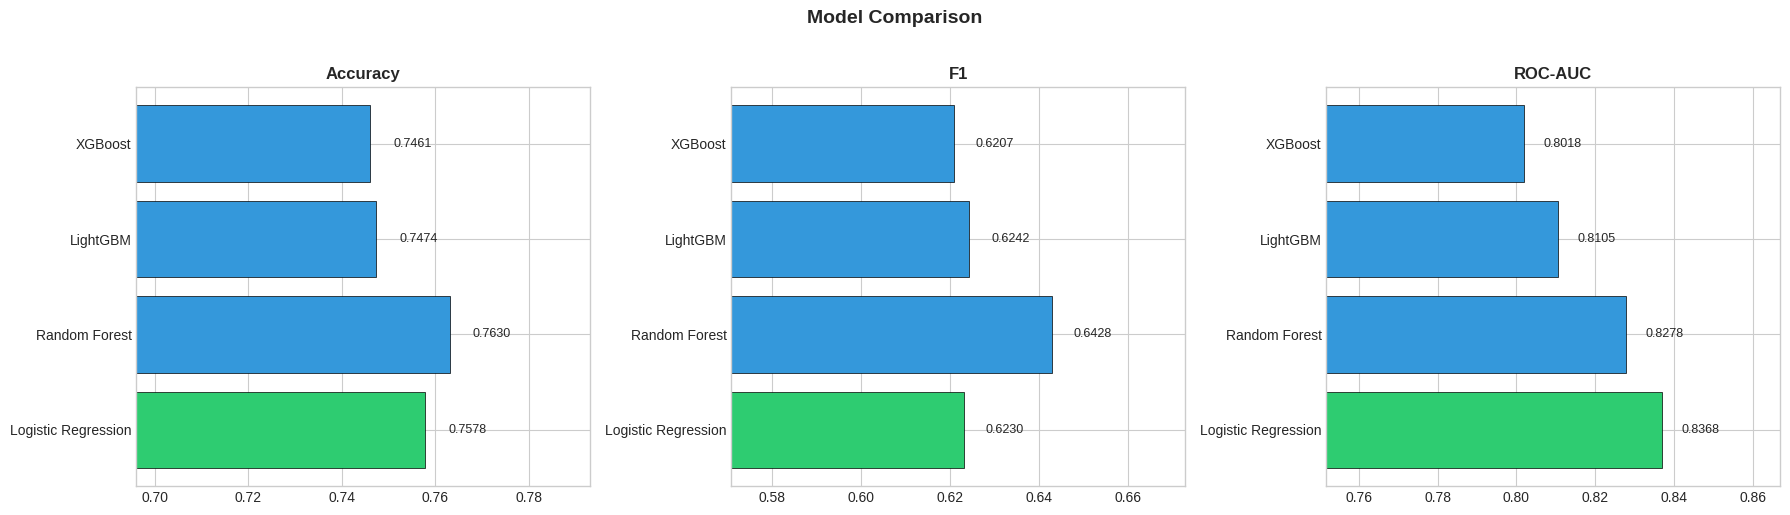

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

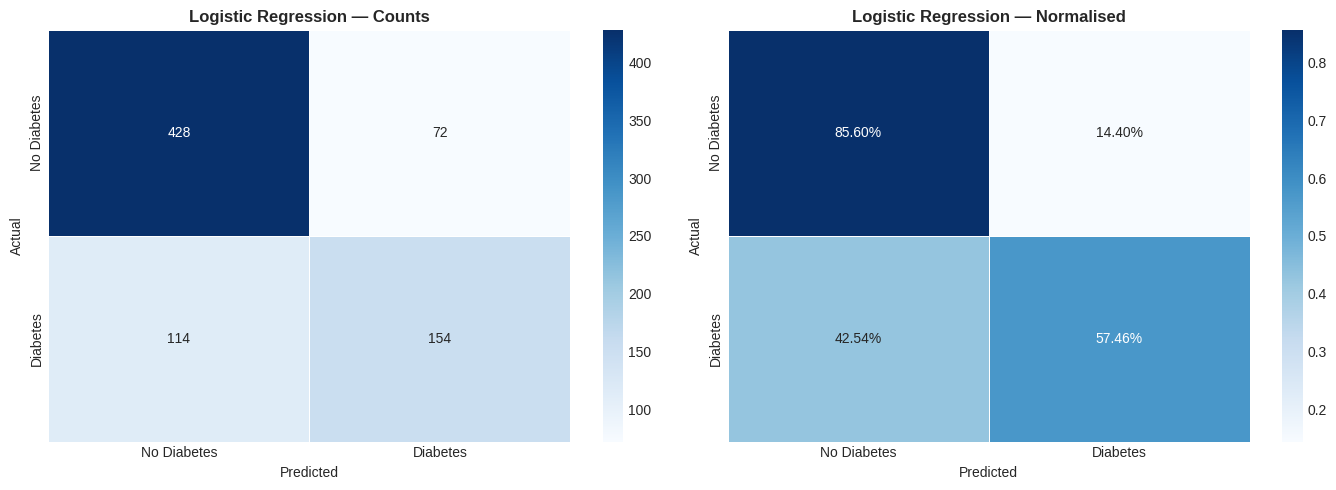


              precision    recall  f1-score   support

 No Diabetes       0.79      0.86      0.82       500
    Diabetes       0.68      0.57      0.62       268

    accuracy                           0.76       768
   macro avg       0.74      0.72      0.72       768
weighted avg       0.75      0.76      0.75       768



In [14]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['No Diabetes', 'Diabetes']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


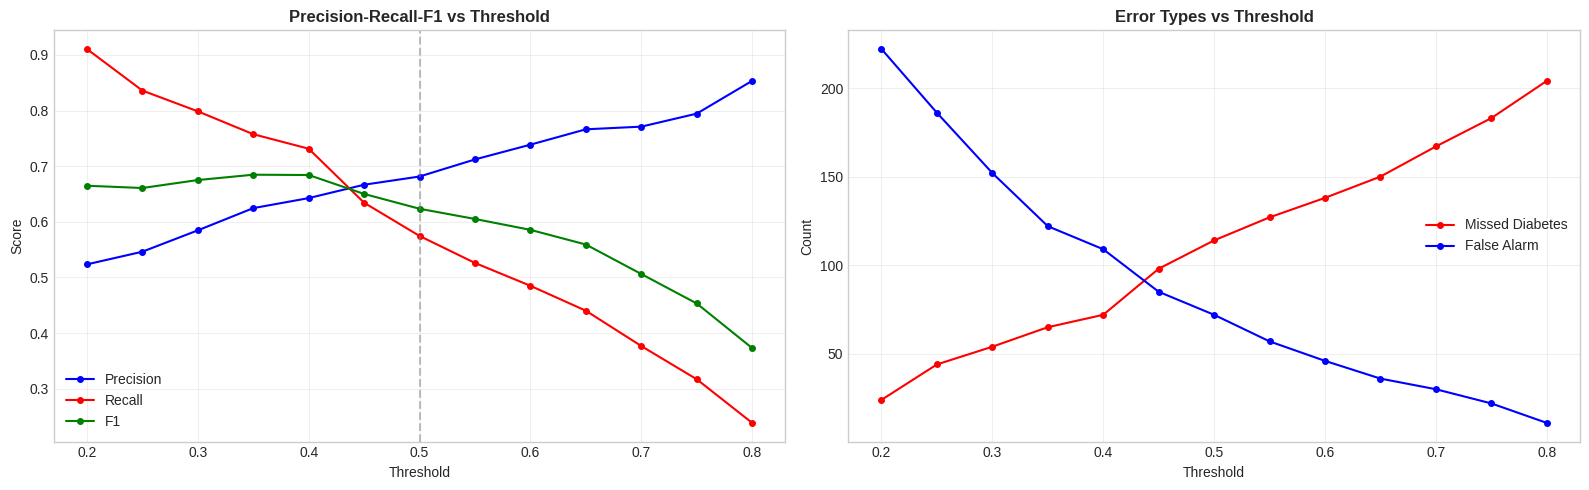


Optimal threshold (F1): 0.35


In [15]:
thresholds = np.arange(0.20, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Diabetes (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alarm (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Diabetes (FN)'], 'r-o', ms=4, label='Missed Diabetes')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alarm (FP)'], 'b-o', ms=4, label='False Alarm')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Policy Insights

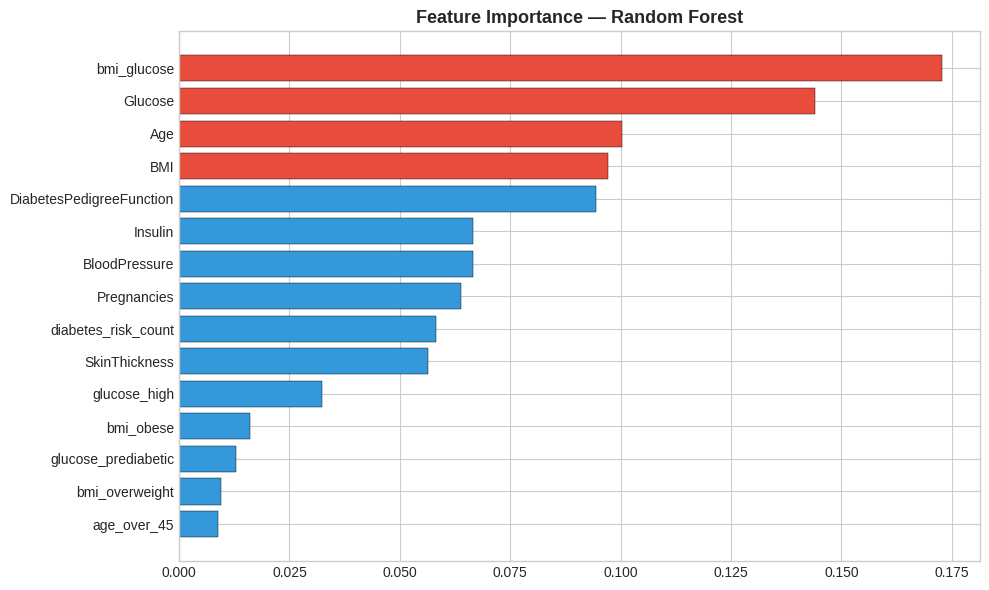

TOP 5 DIABETES RISK PREDICTORS
  bmi_glucose                     0.1728
  Glucose                         0.1440
  Age                             0.1004
  BMI                             0.0971
  DiabetesPedigreeFunction        0.0943

Clinical insight: Glucose level and BMI are consistently the strongest predictors.
Age is a key non-modifiable risk factor. BMI and glucose are modifiable targets.


In [16]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 DIABETES RISK PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:30s}  {row['Importance']:.4f}")
    print("\nClinical insight: Glucose level and BMI are consistently the strongest predictors.")
    print("Age is a key non-modifiable risk factor. BMI and glucose are modifiable targets.")


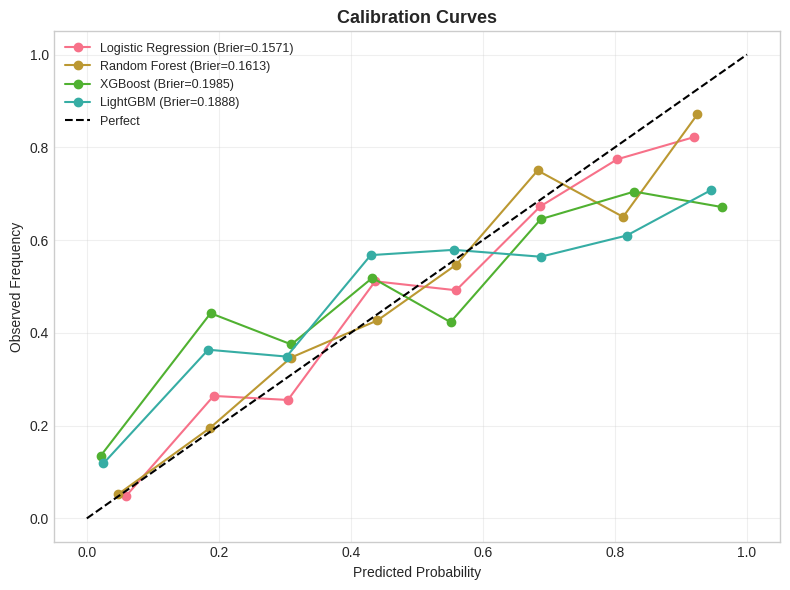

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [18]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.75': best_res['auc_mean'] > 0.75,
    'F1 > 0.55': best_res['f1_mean'] > 0.55,
    'Brier < 0.20': best_res['brier_mean'] < 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Logistic Regression
  ROC-AUC:              0.8368
  F1:                   0.6230
  Precision:            0.6938
  Recall:               0.5747
  Brier Score:          0.1571
  Training time:        1.2s
  Feature count:        15
  Dataset rows:         768
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.35

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.75
  [pass] F1 > 0.55
  [pass] Brier < 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [19]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: GP pathology systems, My Health Record, NDSS registry
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (HbA1c, fasting glucose, BMI, BP)
   Schedule: Real-time at pathology result + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Output: Diabetes risk score + modifiable risk factors + action plan
   Batch: Quarterly PHN diabetes risk stratification by LGA

3. INTEGRATION POINTS
   GP desktop: Risk alert in Best Practice / Medical Director
   Medicare: Trigger CDM items (721/723) for diabetes management
   NDSS: Auto-referral for diabetes education and support
   Pathology: Auto-flag high-risk glucose/HbA1c results
   Allied health: Dietitian/exercise physiologist referral for high BMI

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device classification
   Validation: Against OGTT/HbA1c confirmed diabetes diagnosis
   Explainability: Modifiable risk factors highlighted for patient
   Equity: Monitor Indigenous, CALD, rural/remote populations
   RACGP: Alignment with diabetes screening guidelines

5. MONITORING & RETRAINING
   Drift: PSI on pathology distributions quarterly
   Performance: AUC on confirmed diabetes diagnoses (12-month lag)
   Retraining: Annual with confirmed diagnostic outcomes
   Guidelines: Recalibrate when RACGP/Diabetes Australia guidelines change
   Population: Adjust for increasing obesity prevalence trends

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: GP pathology systems, My Health Record, NDSS registry
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (HbA1c, fasting glucose, BMI, BP)
   Schedule: Real-time at pathology result + quarterly population screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) embedded in GP clinical software
   Output: Diabetes risk score + modifiable risk factors + action plan
   Batch: Quarterly PHN diabetes risk stratification by LGA

3. INTEGRATION POINTS
   GP desktop: Risk alert in Best Practice / Medical Director
   Medicare: Trigger CDM items (721/723) for diabetes management
   NDSS: Auto-referral for diabetes education and support
   Pathology: Auto-flag high-risk glucose/HbA1c results
   Allied health: Dietitian/exercise physiologist referral for high BMI

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device classification
   Va